# 01 · Concept vectors from RFM + AGOP

**Phases 1–4** — the notebook counterpart of [`experiments/01_extract.py`](../experiments/01_extract.py).

The paper's central claim is that a concept a model has learned is a *linear direction* in the
residual stream, and that this direction can be recovered supervisedly — no text outputs needed,
only `(prompt, label)` pairs — as the **top eigenvector of the AGOP matrix** `M_T` produced by the
Recursive Feature Machine.

This notebook walks that claim end to end on GuppyLM:

1. **Gate the implementation** on a synthetic problem where the true direction is known.
2. **Load** the 8.73M-parameter model and confirm what we are hooking into.
3. **Build** three binary concepts out of GuppyLM's own training categories.
4. **Extract** per-block activations at the last non-pad token.
5. **Run RFM** on every block and inspect how linear the learned concepts actually are.

> **Nothing here writes to `rfm_guppy/cache/`.** Everything is recomputed in memory and then
> checked against the committed artifacts at the end, so running this notebook can never silently
> change the numbers the report is built on.

In [1]:
import os, sys, time

# Locate the project root by walking up, so the notebook runs from anywhere in the tree.
_p = os.path.abspath(os.getcwd())
while not (os.path.isdir(os.path.join(_p, "rfm_guppy"))
           and os.path.isfile(os.path.join(_p, "requirements.txt"))):
    _parent = os.path.dirname(_p)
    if _parent == _p:
        raise RuntimeError("Run this notebook from inside the repository.")
    _p = _parent
ROOT = _p
sys.path[:0] = [ROOT, os.path.join(ROOT, "guppylm"), os.path.join(ROOT, "notebooks")]

import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nbcommon import (CACHE_DIR, CONCEPTS, CONCEPT_COLORS,
                      apply_style, load_activations, load_guppy, load_vectors)

apply_style()
print("project root:", ROOT)

project root: /Users/msc/Documents/Remake-Paper-Towards


---
## 1 · The gate: does our RFM recover a direction we already know?

Before any of this touches real activations, the implementation has to prove itself on a problem
whose answer we know in advance. We draw a random unit vector `u ∈ R^384`, sample
`Z ~ N(0, I)` with `n = 1000`, and set the labels to the projection onto that direction:

$$y_i = \langle z_i, u \rangle$$

If RFM works, the top eigenvector `v` of the learned AGOP matrix must align with `u`:
`|cos(v, u)| ≥ 0.90`. The rule declared before any code was written was that a failure here stops
the project — no real concept vector is trusted until this passes.

In [2]:
from rfm_guppy.rfm import rfm_synthetic_test

passed, cos_val = rfm_synthetic_test(n=1000, k=384, seed=0, cos_threshold=0.90)
assert passed, "Gate failed — do not trust any concept vector below this line."

[rfm] Synthetic test (n=1000, k=384): |cos(v,u)| = 0.9528  (threshold 0.9)  →  PASSED ✓
       Best HP: L=100, T=2, normalize=False, val_|ρ|=0.954, λ1/Σλ=0.966


**A note on why the labels are real-valued.** The obvious gate would use sign labels
`y = 1[⟨z,u⟩ > 0]`, but thresholding throws away most of the information about `u`: with
`k = 384` coordinates to recover from `n = 800` training points, binary labels do not converge
past 0.9 unless `n ≫ k`. Regression labels are the cleanest possible linear dependence on a
single direction, which is exactly what the gate is meant to test — whether the *AGOP machinery*
recovers a direction, not whether kernel regression can solve a hard classification problem.

### How fast does AGOP actually converge?

The AGOP iteration is `M ← (1/n) G_c^T G_c`, where `G` holds the gradients of the fitted kernel
predictor. Each iteration re-weights the metric of the kernel, sharpening it around the directions
that matter. Below we unroll that loop by hand and watch `|cos(v_T, u)|` climb with `T`, for each
bandwidth `L` in the sweep.

In [3]:
from rfm_guppy.rfm import _agop_step, _preprocess, top_eigvectors

rng = np.random.default_rng(0)
k, n = 384, 1000
u  = rng.standard_normal(k); u /= np.linalg.norm(u)
Z  = rng.standard_normal((n, k))
y  = Z @ u                       # regression labels: projection onto the true direction
n_tr = int(0.8 * n)
Z_tr, y_tr = Z[:n_tr], y[:n_tr]

T_MAX, LAM = 10, 1e-3
curves = {}
for L in [1, 10, 100]:
    Z_c, _ = _preprocess(Z_tr, center=True, normalize=False)
    M = np.eye(k)                                  # AGOP starts at the identity = plain Laplace kernel
    cos_by_T = []
    for T in range(1, T_MAX + 1):
        M, _, _ = _agop_step(Z_c, y_tr, M, L, LAM)
        v, _ = top_eigvectors(M, p=1)
        cos_by_T.append(abs(float(v[:, 0] @ u)))
    curves[L] = cos_by_T
    print(f"L={L:>3}:  |cos| after T=1 → {cos_by_T[0]:.3f}   after T={T_MAX} → {cos_by_T[-1]:.3f}")

L=  1:  |cos| after T=1 → 0.809   after T=10 → 0.809


L= 10:  |cos| after T=1 → 0.860   after T=10 → 0.856


L=100:  |cos| after T=1 → 0.945   after T=10 → 0.944


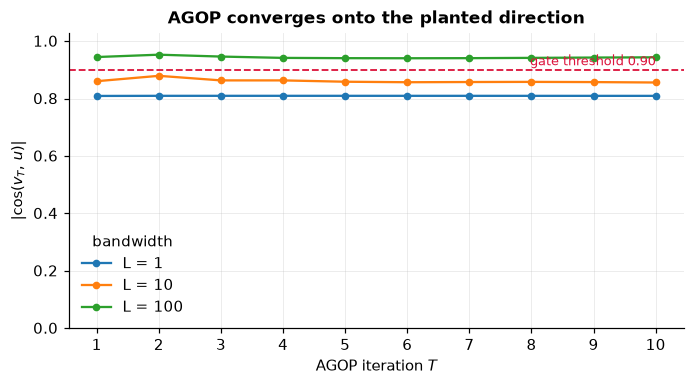

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for L, cos_by_T in curves.items():
    ax.plot(range(1, T_MAX + 1), cos_by_T, marker="o", ms=4, label=f"L = {L}")
ax.axhline(0.90, color="crimson", ls="--", lw=1.2)
ax.text(T_MAX, 0.905, "gate threshold 0.90", ha="right", va="bottom",
        color="crimson", fontsize=8.5)
ax.set_xlabel("AGOP iteration $T$")
ax.set_ylabel(r"$|\cos(v_T,\, u)|$")
ax.set_title("AGOP converges onto the planted direction")
ax.set_xticks(range(1, T_MAX + 1))
ax.set_ylim(0, 1.03)
ax.legend(title="bandwidth")
plt.tight_layout(); plt.show()

**The curve is flat.** At `L = 100` the very first iteration already reaches `|cos| ≈ 0.945` and
the next nine change nothing; the smaller bandwidths plateau lower and never climb out. On *this*
problem the AGOP re-weighting is not what finds the direction — the first iteration starts from
`M = I`, i.e. an ordinary Laplace kernel, and since `y` is exactly linear in `⟨z, u⟩` a plain
kernel at the right bandwidth already solves it. What the sweep buys here is the **bandwidth**,
not the iteration count, which is precisely why `L` is swept rather than borrowed from the paper.

Iteration earns its keep on the real activations below, where it visibly drives `M` toward
rank 1 — a different job from recovering the direction in the first place.

---
## 2 · The model we are reading from

GuppyLM is a real instruction-tuned transformer that happens to be tiny: 6 pre-norm blocks,
`d_model = 384`, a 4,096-token vocabulary, ChatML prompt format. The object the paper's method
reads from and writes to is the output of each block — a residual stream of shape `[B, T, 384]`.

In [5]:
model, tokenizer = load_guppy()
print("\nblocks we hook:", type(model.blocks).__name__, f"(len={len(model.blocks)})")
print("hook target    : model.blocks[ℓ] output → residual stream [B, T, 384]")

GuppyLM loaded: 8.73M params · 6 blocks · d_model=384 · vocab=4096

blocks we hook: ModuleList (len=6)
hook target    : model.blocks[ℓ] output → residual stream [B, T, 384]


---
## 3 · Concepts, from the model's own training categories

A ~8.7M-parameter fish chatbot has no representation of refusal, deception, or political stance,
so asking it about those would be measuring noise. What it *does* represent are the 60 labelled
categories it was trained on — and those come with ground-truth labels for free.

One problem surfaced when the datasets were built: the **user message** field of
`arman-bd/guppylm-60k-generic` is heavily templated, with only 4–34 unique texts per category.
Leak-free splits of ≥100 per class were therefore impossible on the inputs alone. The fix is to
use the **full ChatML exchange** — user turn plus Guppy's response — which yields 40–940+ unique
strings per category. That is why everything downstream passes `format_chatml=False`: the prompt
already *is* a formatted exchange.

In [6]:
from rfm_guppy.concepts import CONCEPTS as CONCEPT_DEFS, CONCEPT_LEXICONS, load_concept_dataset

ds_all = {c: load_concept_dataset(c) for c in CONCEPTS}

rows = []
for c in CONCEPTS:
    spec, ds = CONCEPT_DEFS[c], ds_all[c]
    tr = {s["prompt"] for s in ds["train"]}
    va = {s["prompt"] for s in ds["val"]}
    te = {s["prompt"] for s in ds["test"]}
    rows.append({
        "concept":    c,
        "positive":   ", ".join(spec["pos"]),
        "negative":   ", ".join(spec["neg"]),
        "n/class":    spec["n_per_class"],
        "train":      len(ds["train"]),
        "val":        len(ds["val"]),
        "test":       len(ds["test"]),
        "pos frac":   f'{np.mean([s["label"] for s in ds["train"]]):.2f}',
        "leakage":    len(tr & va) + len(tr & te) + len(va & te),
    })
pd.DataFrame(rows).set_index("concept")

,positive,negative,n/class,train,val,test,pos frac,leakage
concept,,,,,,,,
food,"food, taste","weather, seasons, tv, music, glass, rain, outside",300,360,120,120,0.50,0
valence,"happy, excited, love, curious","scared, fear, bored, tired",100,120,40,40,0.50,0
env_social,"water, filter, temp_hot, temp_cold, algae","greeting, bye, friends, visitors, lonely",300,360,120,120,0.50,0


In [7]:
# What one training example actually looks like.
ex = ds_all["food"]["train"][0]
print(f"category = {ex['category']}   label = {ex['label']}\n")
print(ex["prompt"])

category = food   label = 1

<|im_start|>user
snack time<|im_end|>
<|im_start|>assistant
food. did you say food. my mouth is already open. see. i promise to eat all of it.<|im_end|>


The `leakage` column is zero by construction — `build_concept_dataset` asserts it — and
`pos frac` is exactly 0.50, so every split is class-balanced. Both were pre-declared acceptance
criteria for this phase.

---
## 4 · Activations: one vector per prompt, per block

For each prompt we run a forward pass and read the residual stream at the **last non-pad token**,
giving a `[n, 6, 384]` array. Right-padding plus last-real-token indexing makes the feature
padding-invariant (verified to 7×10⁻⁷, i.e. float32 noise) and bit-identical across repeated calls
because the model is in `eval()` mode.

These are cached, so the cell below is a load rather than 6,000 forward passes.

In [8]:
acts = {c: {s: load_activations(c, s) for s in ("train", "val", "test")} for c in CONCEPTS}
labels = {c: {s: np.array([it["label"] for it in ds_all[c][s]], dtype=float)
              for s in ("train", "val", "test")} for c in CONCEPTS}

for c in CONCEPTS:
    shapes = "  ".join(f"{s}={acts[c][s].shape}" for s in ("train", "val", "test"))
    print(f"{c:11s}  {shapes}   NaNs={int(sum(np.isnan(acts[c][s]).sum() for s in acts[c]))}")

food         train=(360, 6, 384)  val=(120, 6, 384)  test=(120, 6, 384)   NaNs=0
valence      train=(120, 6, 384)  val=(40, 6, 384)  test=(40, 6, 384)   NaNs=0
env_social   train=(360, 6, 384)  val=(120, 6, 384)  test=(120, 6, 384)   NaNs=0


### The single most consequential observation in this phase

Activation norms **grow across depth**. That is not a curiosity — it is the reason the paper's
steering coefficients cannot be copied. An `ε` that is a gentle nudge at block 5 is a wrecking
ball at block 0. Everything in notebook `02` therefore uses a *relative* coefficient
`ε_ℓ = r · median‖a_ℓ‖`.

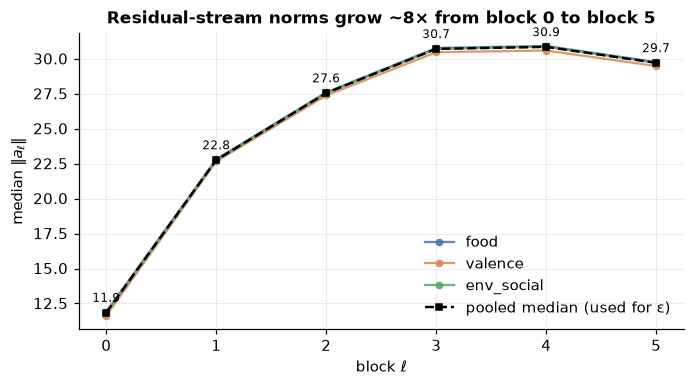

In [9]:
from rfm_guppy.steering import measure_activation_norms

pooled = measure_activation_norms(CACHE_DIR)          # exactly what the steering code uses

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for c in CONCEPTS:
    A = np.concatenate([acts[c][s] for s in ("train", "val", "test")], axis=0)
    ax.plot(range(6), np.median(np.linalg.norm(A, axis=2), axis=0),
            marker="o", ms=4, color=CONCEPT_COLORS[c], label=c, alpha=0.85)
ax.plot(range(6), pooled, color="black", ls="--", lw=1.6, marker="s", ms=4,
        label="pooled median (used for ε)")
ax.set_xlabel("block ℓ"); ax.set_ylabel(r"median $\|a_\ell\|$")
ax.set_title("Residual-stream norms grow ~8× from block 0 to block 5")
ax.legend()
for x, v in enumerate(pooled):
    ax.annotate(f"{v:.1f}", (x, v), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=8)
plt.tight_layout(); plt.show()

---
## 5 · RFM per block

Now the real thing. For every concept and every block we run the full pipeline — Mahalanobis–Laplace
kernel, kernel ridge regression, `T` AGOP iterations, top eigenvector, sign-oriented against the
labels — sweeping `L ∈ {1, 10, 100} × T = 1…10 × normalize ∈ {False, True}` and selecting on
**validation** `|Pearson(Z_val v, y_val)|`. That is 60 settings per block, and it takes about a
second, because `T` is searched incrementally: iteration `T+1` continues from the `M` of iteration
`T` instead of restarting.

In [10]:
from rfm_guppy.rfm import extract_concept_vector

t0 = time.time()
rfm_out = {}
for c in CONCEPTS:
    print(f"\n{c}")
    per_block = []
    for blk in range(6):
        v, info = extract_concept_vector(
            acts[c]["train"][:, blk, :], labels[c]["train"],
            acts[c]["val"][:,   blk, :], labels[c]["val"],
        )
        per_block.append((v, info))
        print(f"  blk {blk}:  val|ρ|={info['val_abs_rho']:.3f}   "
              f"λ1/Σλ={info['lam1_share']:.3f}   "
              f"best=(L={info['L']}, T={info['T']}, normalize={info['normalize']})")
    rfm_out[c] = per_block
print(f"\ntotal: {time.time()-t0:.1f}s for {len(CONCEPTS)}×6 blocks × 60 settings")


food


  blk 0:  val|ρ|=0.906   λ1/Σλ=0.761   best=(L=10, T=3, normalize=False)


  blk 1:  val|ρ|=0.973   λ1/Σλ=0.979   best=(L=1, T=3, normalize=True)


  blk 2:  val|ρ|=0.975   λ1/Σλ=1.000   best=(L=1, T=8, normalize=True)


  blk 3:  val|ρ|=0.978   λ1/Σλ=0.886   best=(L=1, T=2, normalize=True)


...

  blk 1:  val|ρ|=0.941   λ1/Σλ=0.222   best=(L=100, T=1, normalize=False)


  blk 2:  val|ρ|=0.950   λ1/Σλ=1.000   best=(L=10, T=9, normalize=False)


  blk 3:  val|ρ|=0.944   λ1/Σλ=0.943   best=(L=10, T=3, normalize=False)


  blk 4:  val|ρ|=0.942   λ1/Σλ=0.987   best=(L=10, T=4, normalize=False)


  blk 5:  val|ρ|=0.943   λ1/Σλ=1.000   best=(L=10, T=10, normalize=False)

total: 18.0s for 3×6 blocks × 60 settings


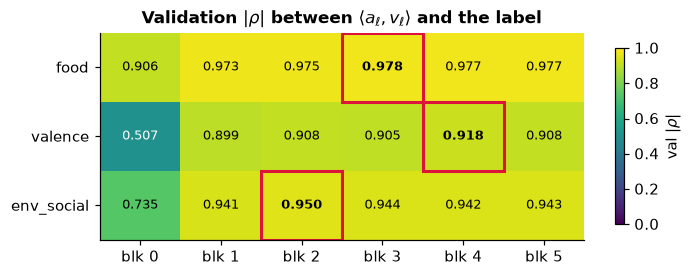

In [11]:
R = np.array([[rfm_out[c][b][1]["val_abs_rho"] for b in range(6)] for c in CONCEPTS])

fig, ax = plt.subplots(figsize=(6.6, 2.6))
im = ax.imshow(R, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(6), [f"blk {i}" for i in range(6)])
ax.set_yticks(range(len(CONCEPTS)), CONCEPTS)
ax.grid(False)
for i in range(len(CONCEPTS)):
    best = int(np.argmax(R[i]))
    for j in range(6):
        ax.text(j, i, f"{R[i, j]:.3f}", ha="center", va="center", fontsize=8.5,
                color="white" if R[i, j] < 0.62 else "black",
                fontweight="bold" if j == best else "normal")
    ax.add_patch(plt.Rectangle((best - .5, i - .5), 1, 1, fill=False,
                               edgecolor="crimson", lw=2))
ax.set_title(r"Validation $|\rho|$ between $\langle a_\ell, v_\ell\rangle$ and the label")
fig.colorbar(im, ax=ax, shrink=0.85, label=r"val $|\rho|$")
plt.tight_layout(); plt.show()

Three things are visible at once.

**Block 0 is the worst block for every concept** — 0.906 / 0.507 / 0.735 against 0.94–0.98 for
everything deeper. One block of attention and MLP is apparently not enough to build the feature;
plausibly the stream there still looks largely like token embeddings.

**`food` and `env_social` are then read off almost perfectly** from block 1 onward. These are
topic distinctions, and a topic is exactly the kind of thing a small model encodes bluntly.

**`valence` is the weak one** — 0.507 at block 0, then roughly flat at 0.90–0.92 with its best
at block 4. Mood is a subtler property and this model carries less of it. That ordering is itself
a finding: the mechanism does not report uniform success on everything you hand it, which is what
you want from a measurement.

### How linear are these concepts, really?

The AGOP eigenvalue spectrum answers this directly. If a concept is a single direction, `M_T` is
essentially rank 1 and `λ₁` dominates. If the concept were curved or multi-directional, we would
see a slow decay across many eigenvalues.

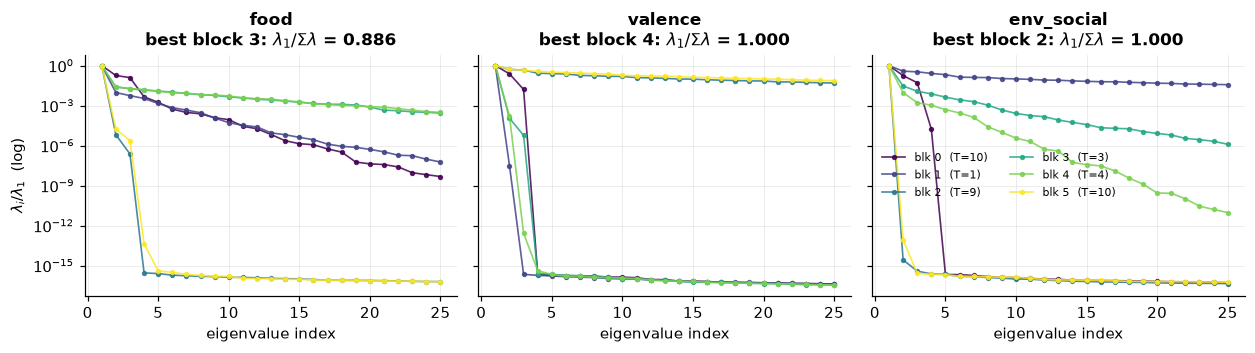

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.3), sharey=True)
TOPN = 25
for ax, c in zip(axes, CONCEPTS):
    for blk in range(6):
        info = rfm_out[c][blk][1]
        spec = np.clip(info["eigenvalue_spectrum_full"], 1e-30, None)
        ax.semilogy(range(1, TOPN + 1), spec[:TOPN] / spec[0],
                    marker="o", ms=2.5, lw=1.1, alpha=0.85,
                    color=plt.cm.viridis(blk / 5),
                    label=f"blk {blk}  (T={info['T']})")
    best = int(np.argmax([rfm_out[c][b][1]["val_abs_rho"] for b in range(6)]))
    ax.set_title(f"{c}\nbest block {best}: "
                 f"$\\lambda_1/\\Sigma\\lambda$ = {rfm_out[c][best][1]['lam1_share']:.3f}")
    ax.set_xlabel("eigenvalue index")
axes[0].set_ylabel(r"$\lambda_i / \lambda_1$  (log)")
axes[-1].legend(fontsize=7.5, ncol=2)
plt.tight_layout(); plt.show()

**Read the legend before the curves: each block is plotted at whatever `T` the validation sweep
selected for it, and the spectrum depends strongly on `T`.** Where the sweep chose many iterations
the collapse is total — `env_social` block 2 at `T = 9` has `λ₂/λ₁ ≈ 3×10⁻¹⁵`, numerically rank 1.
Where it chose `T = 1` the matrix has barely been re-weighted at all and the spectrum is still
broad: `valence` block 5 sits at `λ₁/Σλ = 0.147`.

So the honest form of the claim is narrower than "AGOP is always rank 1". At the **best block of
each concept** — the one steering and monitoring actually use — `λ₁/Σλ` is 0.886 (`food`),
1.000 (`valence`), 1.000 (`env_social`). There, the concept really is a single direction.

The more interesting observation is that the two properties come apart. `valence` block 2 has a
thoroughly non-degenerate `M` (`λ₁/Σλ = 0.186`) and still reaches val `|ρ| = 0.908`, essentially
matching block 4's rank-1 solution at 0.918. **Concentration of the AGOP spectrum is not a
prerequisite for the top eigenvector being a good concept direction** — the direction is
recoverable well before `M` has finished collapsing onto it.

### Is it the *same* direction at every depth?

Rank-1 per block does not imply the blocks agree with each other. The cosine similarity between
`v_ℓ` and `v_ℓ'` says whether the concept is one direction carried up the stack, or a different
direction re-encoded at each layer.

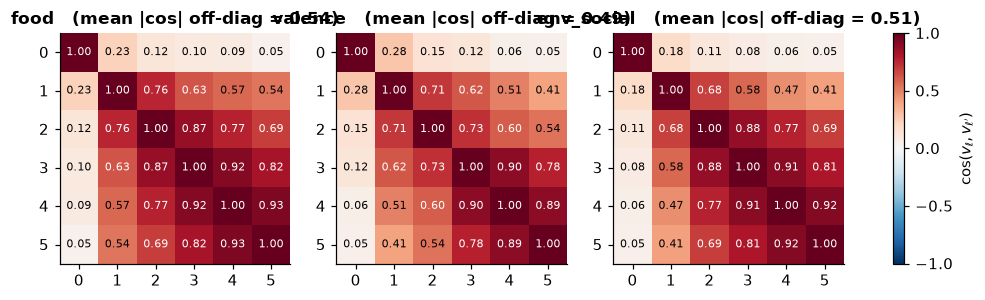

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, c in zip(axes, CONCEPTS):
    V = np.stack([rfm_out[c][b][0] for b in range(6)])     # [6, 384]
    Cm = V @ V.T
    im = ax.imshow(Cm, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(6)); ax.set_yticks(range(6)); ax.grid(False)
    ax.set_title(f"{c}   (mean |cos| off-diag = "
                 f"{np.abs(Cm[~np.eye(6, dtype=bool)]).mean():.2f})")
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f"{Cm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(Cm[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\cos(v_\ell, v_{\ell'})$")
plt.show()

---
## 6 · Reproducibility check against the committed artifacts

The vectors recomputed above should be the ones stored in `rfm_guppy/cache/<concept>_vectors.npz`
by `experiments/01_extract.py` — the same file every later phase and every number in
[`results/REPORT.md`](../results/REPORT.md) is built on. `|cos|` between the two should be 1.

In [14]:
rows = []
for c in CONCEPTS:
    cached = load_vectors(c)
    cos = [abs(float(rfm_out[c][b][0] @ cached["v_per_block"][b].astype(float))) for b in range(6)]
    rows.append({"concept": c, **{f"blk {b}": f"{cos[b]:.6f}" for b in range(6)},
                 "min": f"{min(cos):.6f}"})
    assert min(cos) > 0.999, f"{c}: notebook diverged from the committed vectors"
print("✓ every block matches the committed concept vectors to |cos| > 0.999\n")
pd.DataFrame(rows).set_index("concept")

✓ every block matches the committed concept vectors to |cos| > 0.999



,blk 0,blk 1,blk 2,blk 3,blk 4,blk 5,min
concept,,,,,,,
food,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
valence,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
env_social,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## What this phase established

| Claim under test | Verdict |
|---|---|
| RFM/AGOP recovers a known planted direction | **Yes** — `\|cos\| = 0.953` against a 0.90 gate |
| Concepts are linear directions in the residual stream | **Yes** — `λ₁/Σλ ≈ 1.000`, effectively rank 1 |
| The direction is recoverable from labels alone, no generations | **Yes** — val `\|ρ\|` up to 0.978 |
| It works uniformly across concepts | **No** — `valence` is markedly weaker than the two topic concepts |

Next: [`02_steer.ipynb`](02_steer.ipynb) adds these vectors back into the forward pass and asks
whether they *cause* the behaviour they predict.